# VATIX video inference

Load the trajectory-conditioned VATIX checkpoint from Hugging Face, generate a future video from the first frame of a real clip, and compare the result with the ground-truth video. Run the notebook from the repository environment.

In [1]:
from pathlib import Path
import sys

import imageio.v3 as iio
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Video, display
from huggingface_hub import snapshot_download
from hydra import compose, initialize_config_dir
from hydra.core.hydra_config import HydraConfig

def find_repo_root():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "vatix").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook inside the VATIX repository.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLIP_ID = "clip_05368"
GT_PATH = REPO_ROOT / "real_videos" / "Nuscenes_traj_samples" / f"{CLIP_ID}.mp4"
TRAJECTORY_PATH = GT_PATH.with_suffix(".npy")
MODEL_ROOT = REPO_ROOT / "ckpt" / "huggingface_vatix"
VAE_ROOT = REPO_ROOT / "ckpt"
print(f"Repository: {REPO_ROOT}")
print(f"Device: {DEVICE}")
print(f"Ground truth: {GT_PATH}")

/opt/conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Repository: /home/victor/workspace/git_public/VATIX
Device: cuda
Ground truth: /home/victor/workspace/git_public/VATIX/real_videos/Nuscenes_traj_samples/clip_05368.mp4


## Download the published weights

The transformer and EMA weights are about 9.5 GB. This cell is cached by `huggingface_hub`, so it only downloads missing files.

In [2]:
HF_REPO_ID = "llvictorll/Vatix"
HF_REVISION = "main"

# Vatix Flow Matching Model  
snapshot_download(
    repo_id=HF_REPO_ID,
    revision=HF_REVISION,
    local_dir=MODEL_ROOT,
    allow_patterns=[
        "1B_traj/ckpt/200000/model_state_dict.pt",
        "1B_traj/ckpt/200000/ema_state_dict.pt",
        "1B_traj/ckpt/200000/meta.json",
    ],
)
# WAN 2.1 Vae 
snapshot_download(
    repo_id=HF_REPO_ID,
    revision=HF_REVISION,
    local_dir=VAE_ROOT,
    allow_patterns=["wan21/wan_2.1_vae.pth"],
)
print("Weights are ready.")

Fetching 1 files: 100%|███████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 116.81it/s]

Weights are ready.


In [3]:
import yaml
from argparse import Namespace
from vatix.trainer import FM

config_path = REPO_ROOT / "conf" / "experiment" / "base.yaml"

with open(config_path, 'r') as file:
    config_dict = yaml.safe_load(file)

args = Namespace(**config_dict)

args.vit_folder =  str(REPO_ROOT / "ckpt" / "huggingface_vatix" / "1B_traj") + "/"
args.vqgan_folder = str(REPO_ROOT / "ckpt" / "wan21") + "/"
args.test_only = True
args.resume = True
args.vit_size = "giant"
args.use_trajectory_cond = True
args.use_ema = True

args.device = DEVICE
args.iter = 0
args.global_epoch = 0
args.global_rank = 0
args.is_master = True
args.is_multi_gpus = False
args.nb_gpus = 1
args.num_nodes = 1
args.bsize = 1

fm = FM(args)
print("VATIX model loaded.")

Init Img-to-Vid Flow Matching on [GPU0]
Size of model vit: 1188.108M
[optim] trajectory param group: 8 tensors at weight_decay=0; base group: 405 tensors
Resuming from checkpoint in /home/victor/workspace/git_public/VATIX/ckpt/huggingface_vatix/1B_traj/
Resumed from checkpoint in 4.26 seconds

=== Run Parameters ===
bsize                         : 1
cameras                       : ['FRONT']
compile                       : False
data                          : mp4
data_folder                   : ./real_videos
data_fraction                 : 1.0
debug                         : False
device                        : cuda
dist_backend                  : ddp
drop_label                    : 0.1
dropout                       : 0.05
dtype                         : bfloat16
ema_decay                     : 0.9995
epoch                         : 10000
eval_folder                   : ./real_videos
eval_max_iter                 : -1
exp_name                      : ${prefix_name}${hydra:runtime.choic

## Generate and compare one clip (Zero-Shot on nuScenes)

Change `CLIP_ID` in the first code cell to inspect another matching `.mp4` and `.npy` pair from `real_videos/Nuscenes_traj_samples`.

In [4]:
gt_frames = np.stack(list(iio.imiter(GT_PATH)), axis=0)
trajectory = torch.from_numpy(np.load(TRAJECTORY_PATH)).float().unsqueeze(0).to(DEVICE)

context = torch.from_numpy(gt_frames[0]).permute(2, 0, 1).float()
context = F.interpolate(
    context[None], size=tuple(args.img_size), mode="bilinear", align_corners=False
)
x_ctx = context.unsqueeze(2).repeat(1, 1, args.n_frames, 1, 1).to(DEVICE)

with torch.inference_mode(), fm.ema_scope():
    sample = fm.generation_helper.generate_samples(
        x_ctx=x_ctx,
        latent_context=1,
        num_steps=20,
        alpha=0.0,
        trajectory=trajectory,
        cfg_w=3.0,
        shared_noise=True,
    )

generated_frames = ((sample[0].clamp(-1, 1) + 1.0) * 127.5)
generated_frames = generated_frames.permute(1, 2, 3, 0).byte().cpu().numpy()
print(f"Ground truth: {gt_frames.shape}, generated: {generated_frames.shape}")

Ground truth: (25, 320, 416, 3), generated: (25, 320, 416, 3)


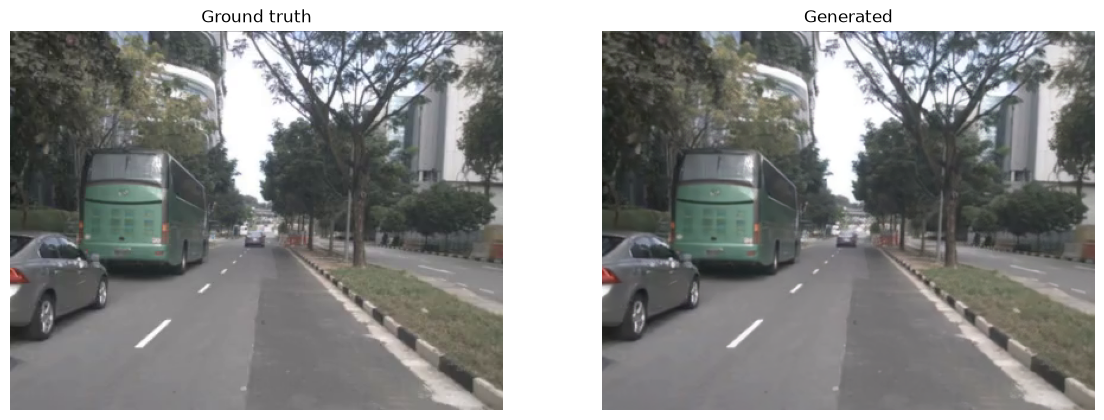

Saved side-by-side video to /home/victor/workspace/git_public/VATIX/clip_05368_ground_truth_vs_generated.mp4


In [5]:
comparison_frames = np.concatenate(
    [gt_frames[: len(generated_frames)], generated_frames], axis=2
)
comparison_path = REPO_ROOT / f"{CLIP_ID}_ground_truth_vs_generated.mp4"
iio.imwrite(comparison_path, comparison_frames, fps=10)
print(
display(Video(str(comparison_path), embed=True, width=832))
print(f"Saved side-by-side video to {comparison_path}")